In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
%pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


In [2]:
def get_abs_pos(chrom, chrom_pos):
    return (chrom_pos - 1) + dict(enumerate(chr_offsets))[chrom - 1]    


In [3]:
yeast_chr_lengths = [
    230218, 813184, 316620, 1531933, 576874, 270161, 1090940, 562643,
    439888, 745751, 666816, 1078177, 924431, 784333, 1091291, 948066
]
yeast_chr_size = np.array(yeast_chr_lengths).sum()

chr_labels_arabic = [str(i) for i in range(1, 17)]
chr_offsets = np.cumsum([0] + yeast_chr_lengths[:-1])

In [4]:
# Path to your Excel file
file_path = "./data/NgyenBa2021_supp_data/elife-73983-supp2-v2.xlsx"

# Read all sheets into a dictionary of DataFrames
all_sheets = pd.read_excel(file_path, sheet_name=None)

# Each key is the sheet name, and each value is a DataFrame
for sheet_name, df in all_sheets.items():
    print(f"Loaded sheet: {sheet_name} -> shape: {df.shape}")

# Optionally, unpack into individual variables
for sheet_name, df in all_sheets.items():
    globals()[f"df_{sheet_name}"] = df

Loaded sheet: 23C -> shape: (112, 10)
Loaded sheet: 25C -> shape: (134, 10)
Loaded sheet: 27C -> shape: (149, 10)
Loaded sheet: 30C -> shape: (159, 10)
Loaded sheet: 33C -> shape: (147, 10)
Loaded sheet: 35C -> shape: (117, 10)
Loaded sheet: 37C -> shape: (128, 10)
Loaded sheet: 4NQO -> shape: (153, 10)
Loaded sheet: cu -> shape: (143, 10)
Loaded sheet: eth -> shape: (149, 10)
Loaded sheet: li -> shape: (83, 10)
Loaded sheet: gu -> shape: (185, 10)
Loaded sheet: mann -> shape: (169, 10)
Loaded sheet: mol -> shape: (111, 10)
Loaded sheet: raff -> shape: (167, 10)
Loaded sheet: sds -> shape: (175, 10)
Loaded sheet: suloc -> shape: (173, 10)
Loaded sheet: ynb -> shape: (145, 10)


(112, 10)
(134, 10)
(149, 10)
(159, 10)
(147, 10)
(117, 10)
(128, 10)
(153, 10)
(143, 10)
(149, 10)
(83, 10)
(185, 10)
(169, 10)
(111, 10)
(167, 10)
(175, 10)
(173, 10)
(145, 10)


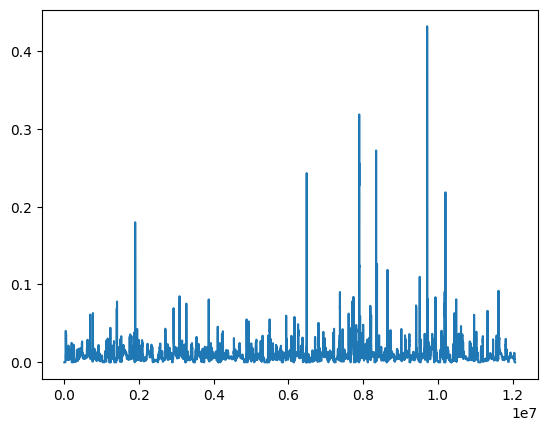

In [5]:
CI_track = np.zeros(yeast_chr_size)

for df in list(all_sheets.values()):
    print(df.shape)
    for index, row in df.iterrows():
        start, end = row['CI start position'], row['CI end position']
        chrom = row['Chromosome']
        start, end = get_abs_pos(chrom, start), get_abs_pos(chrom, end)
        effect_size = np.abs(row['Effect size'])
        CI_track[start: end + 1] += effect_size

plt.plot(np.arange(yeast_chr_size), CI_track)

(112, 10)
(134, 10)
(149, 10)
(159, 10)
(147, 10)
(117, 10)
(128, 10)
(153, 10)
(143, 10)
(149, 10)
(83, 10)
(185, 10)
(169, 10)
(111, 10)
(167, 10)
(175, 10)
(173, 10)
(145, 10)


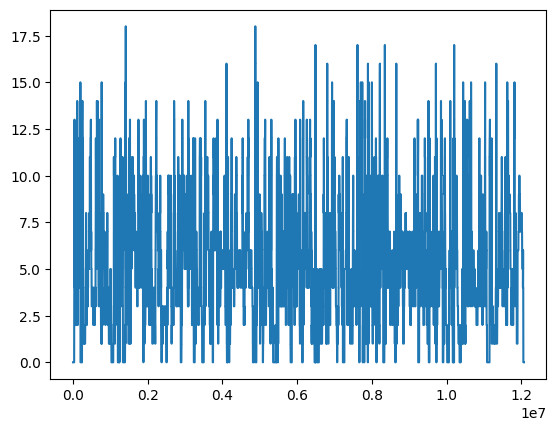

In [7]:
CI_track_ = np.zeros(yeast_chr_size)

for df in list(all_sheets.values()):
    print(df.shape)
    for index, row in df.iterrows():
        start, end = row['CI start position'], row['CI end position']
        chrom = row['Chromosome']
        start, end = get_abs_pos(chrom, start), get_abs_pos(chrom, end)
        effect_size = 1
        CI_track_[start: end + 1] += effect_size

plt.plot(np.arange(yeast_chr_size), CI_track_)
plt.show()

In [8]:
pd.DataFrame({'abs_pos': np.arange(yeast_chr_size), 'CI_track': CI_track}).to_csv("pleiotropic_CI.csv", index=None)
pd.DataFrame({'abs_pos': np.arange(yeast_chr_size), 'CI_track': CI_track_}).to_csv("pleiotropic_CI_unweighted.csv", index=None)

In [11]:
from pathlib import Path
from src.prepare_data import yeast_geno_data, yeast_fitness_data, yeast_data

path = Path("/orange/juannanzhou/MarginalEpistasis/data/")
geno_data_path = path / "geno_top_25.npy"
ids_path = path / "index_top_25.tsv"
snp_info_path = "../data/snp_info_complete.tsv"
gene_info_path = "../data/gene_info.csv"

geno_data = yeast_geno_data(geno_data_path, ids_path, snp_info_path, gene_info_path)
geno_data.sub_sample_snps(r2_threshold=.99)

/blue/juannanzhou/juannanzhou/conda/envs/gpy3/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
gene_info = pd.read_csv(gene_info_path)

In [14]:
gene_info[gene_info.Standard_name == 'MKT1'][['chrom', 'gene_chr_start','gene_chr_end']].to_numpy()

array([[    14, 467131, 469623]])

In [15]:
chrom, start, end = gene_info[gene_info.Standard_name == 'MKT1'][['chrom', 'gene_chr_start','gene_chr_end']].to_numpy().flatten()

In [17]:
start, end = get_abs_pos(chrom, start), get_abs_pos(chrom, end)

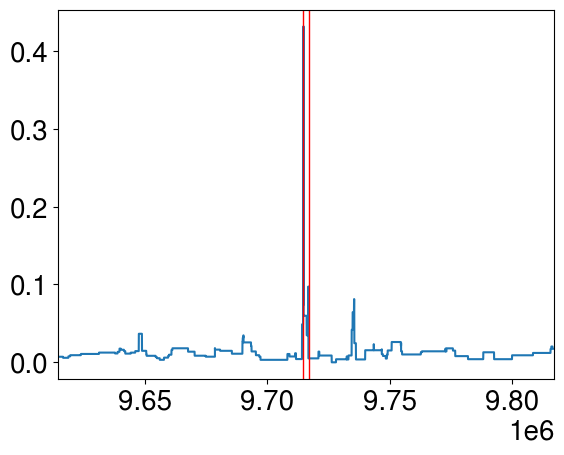

In [18]:
plt.plot(np.arange(yeast_chr_size), CI_track)
plt.xlim(start - 100000, end + 100000)
plt.axvline(x=start, color='red', linestyle='-', linewidth=1, label='Start')
plt.axvline(x=end - 1, color='red', linestyle='-', linewidth=1, label='End')

In [19]:
pd.DataFrame({'abs_pos': np.arange(yeast_chr_size), 'CI_track': CI_track}).to_csv("pleiotropic_CI.csv", index=None)

(112, 10)
(134, 10)
(149, 10)
(159, 10)
(147, 10)
(117, 10)
(128, 10)
(153, 10)
(143, 10)
(149, 10)
(83, 10)
(185, 10)
(169, 10)
(111, 10)
(167, 10)
(175, 10)
(173, 10)
(145, 10)


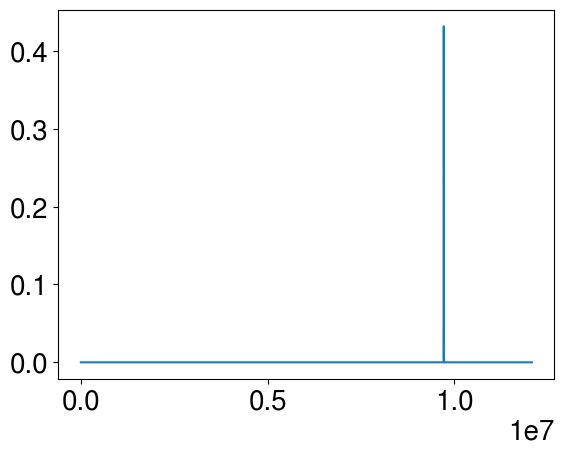

In [20]:
CI_track = np.zeros(yeast_chr_size)
effect = 0
for df in list(all_sheets.values()):
    print(df.shape)
    for index, row in df.iterrows():
        genes = row['Genes']
        try:
            if 'MKT1' in genes:
                start, end = row['CI start position'], row['CI end position']
                chrom = row['Chromosome']
                start, end = get_abs_pos(chrom, start), get_abs_pos(chrom, end)
                effect_size = np.abs(row['Effect size'])
                effect += effect_size
                CI_track[start: end + 1] += effect_size
            else: pass
        except: pass

plt.plot(np.arange(yeast_chr_size), CI_track)

In [23]:
index, row = next(df.iterrows())

In [24]:
row

QTL                          1
Effect size          -0.016814
Lead SNP index           34743
CI start index           34742
CI end index             34744
Chromosome                  14
Lead SNP position       467023
CI start position       466583
CI end position         467214
Genes                SNN1;MKT1
Name: 0, dtype: object